In [37]:
# Import the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from jsonschema.benchmarks.subcomponents import hmap

# Load the Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')


titanic = sns.load_dataset("titanic")
titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [38]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [39]:
titanic.shape

(891, 15)

In [40]:
# Check for missing values in the dataset
titanic.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [41]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [42]:
titanic.describe(include="category")

,class,deck
count,891,203
unique,3,7
top,Third,C
freq,491,59


In [43]:
print("Dataset info before handling missing values:")
titanic.info()

if 'deck' in titanic.columns:
    titanic = titanic.drop(columns=['deck'])

# Fill missing 'age' values with the median
titanic['age'] = titanic['age'].fillna(titanic['age'].median())

# Fill missing 'embarked' values with the mode
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])

# Drop rows where 'embark_town' is missing
titanic.dropna(subset=['embark_town'])

print("Dataset info after handling missing values:")
titanic.info()

Dataset info before handling missing values:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
Dataset info after handling missing values:
<clas

In [46]:
# Display dataset info before data type conversion
print("Dataset Info before data type conversion:")
titanic.info()

titanic['sex'] = titanic['sex'].astype('category')
titanic['embarked'] = titanic['embarked'].astype('category')
titanic['class'] = titanic['class'].astype('category')
titanic['who'] = titanic['who'].astype('category')
titanic['adult_male'] = titanic['adult_male'].astype('category')
titanic['alone'] = titanic['alone'].astype('category')

print("Dataset Info after data type conversion:")
titanic.info()


Dataset Info before data type conversion:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    category
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    category
 8   class        891 non-null    category
 9   who          891 non-null    category
 10  adult_male   891 non-null    category
 11  embark_town  889 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    category
dtypes: category(6), float64(2), int64(4), str(2)
memory usage: 61.3 KB
Dataset Info after data type conversion:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Da

In [47]:
# Removing duplicates

duplicates = titanic.duplicated().sum()
print(f"Number of duplicate rows:{duplicates}")

if duplicates > 0:
    titanic = titanic.drop_duplicates()

duplicates = titanic.duplicated().sum()
print(f"Number of duplicate rows after dropping:{duplicates}")

Number of duplicate rows:116
Number of duplicate rows after dropping:0


In [48]:
# Check the dataset info after data cleaning
titanic.info()

<class 'pandas.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    category
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     775 non-null    category
 8   class        775 non-null    category
 9   who          775 non-null    category
 10  adult_male   775 non-null    category
 11  embark_town  773 non-null    str     
 12  alive        775 non-null    str     
 13  alone        775 non-null    category
dtypes: category(6), float64(2), int64(4), str(2)
memory usage: 59.3 KB


# Data Analysis by Visualization
##### Data Analysis by Visualization is a critical step in understanding the underlying patterns, anomalies, and relationships within a dataset. It involves various techniques to summarize the main characteristics of the data, often using visual methods. It helps in identifying trends, spotting anomalies, testing hypotheses, and checking assumptions. This comprehensive analysis will cover univariate, bivariate, and multivariate analysis.

4.1 Univariate Analysis
Univariate analysis focuses on examining one variable at a time. It helps in understanding the distribution, central tendency, and variability of individual variables.

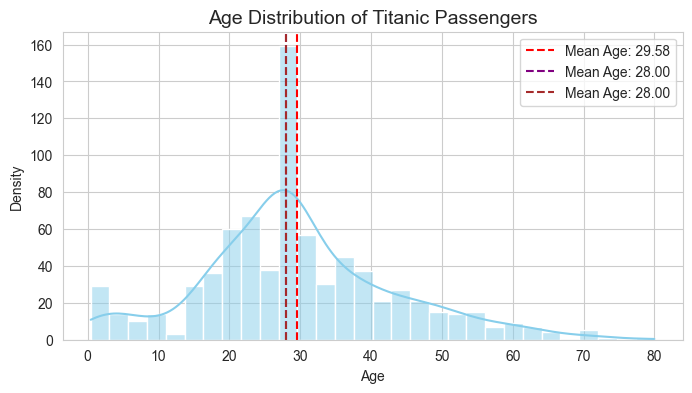

In [63]:
## Age Distribution Plot

sns.set_style("whitegrid")
plt.figure(figsize=(8,4))
sns.histplot(data=titanic['age'].dropna(), bins = 30, kde = True, color='skyblue')

plt.title('Age Distribution of Titanic Passengers', fontdict={'fontsize':14})
plt.xlabel('Age')
plt.ylabel('Density')

mean_age = titanic['age'].mean()
plt.axvline(mean_age, color = 'red', linestyle = '--', linewidth = 1.5, label = f'Mean Age: {mean_age:.2f}')

median_age = titanic['age'].median()
plt.axvline(median_age, color = 'purple', linestyle = '--', linewidth = 1.5, label = f'Mean Age: {median_age:.2f}')

mode_age = titanic['age'].mode()[0]
plt.axvline(mode_age, color = 'brown', linestyle = '--', linewidth = 1.5, label = f'Mean Age: {mode_age:.2f}')

plt.legend()

plt.show()


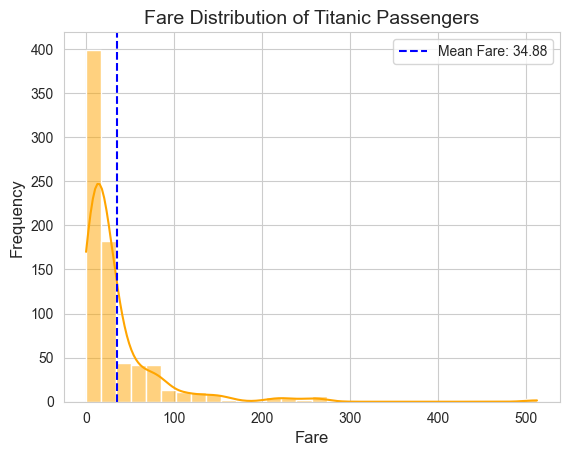

In [64]:
#Fare Distribution Plot.

# Plot the distribution of fare with a different color
sns.histplot(titanic['fare'].dropna(), bins=30, kde=True, color='orange')

# Add titles and labels
plt.title('Fare Distribution of Titanic Passengers', fontsize=14)
plt.xlabel('Fare', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add a vertical line for the mean fare
mean_fare = titanic['fare'].mean()
plt.axvline(mean_fare, color='blue', linestyle='--', linewidth=1.5, label=f'Mean Fare: {mean_fare:.2f}')

# Add a legend
plt.legend()

# Show the plot
plt.show()

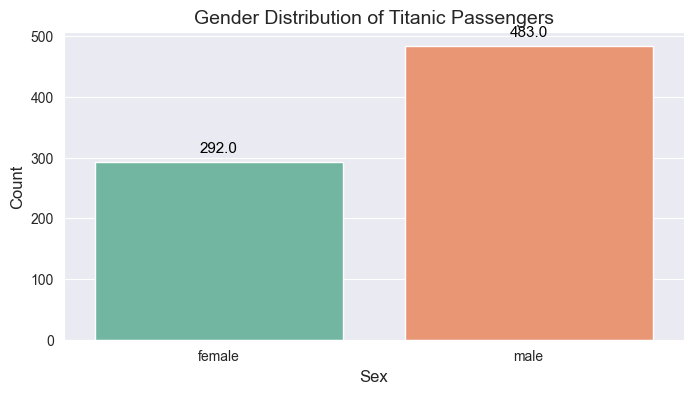

In [71]:
qx  #Gender Distribution Plot.

import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.figure(figsize=(8,4))

sns.countplot(data = titanic, x = 'sex', palette='Set2')

plt.title('Gender Distribution of Titanic Passengers', fontsize=14)
plt.xlabel('Sex', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Annotate the bars with the count of each category
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                       textcoords='offset points')

plt.show()



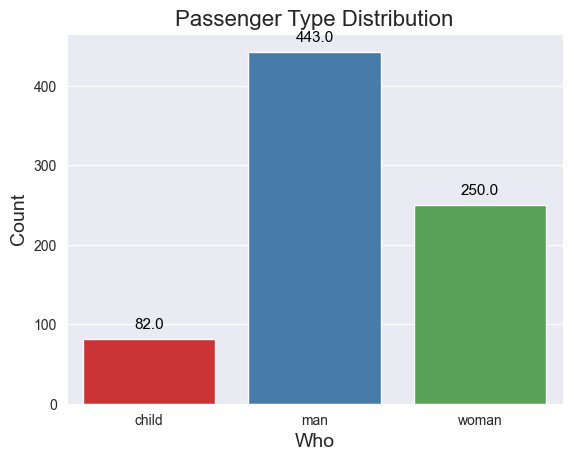

In [73]:
# Passenger Type Distribution Plot

sns.countplot(data = titanic, x = 'who', palette='Set1')
# Add titles and labels with improved font sizes
plt.title('Passenger Type Distribution', fontsize=16)
plt.xlabel('Who', fontsize=14)
plt.ylabel('Count', fontsize=14)

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                       textcoords='offset points')

# Show the plot
plt.show()


4.2 Bivariate Analysis
Bivariate analysis refers to the statistical analysis of two variables, with the aim of determining the empirical relationship between them. This type of analysis is essential in understanding how two different factors interact with one another and can provide insights that are not apparent when analyzing each variable individually.

Bivariate analysis helps in identifying whether a relationship exists between two variables and the nature of that relationship (positive, negative, or no correlation).

Example:
In the context of the Titanic dataset, conducting a bivariate analysis of age and fare can reveal several insights:

Analyzing whether certain age groups had a higher or lower probability of survival based on the fare they paid for their tickets. For instance, it might be observed that younger passengers who paid higher fares had a higher survival rate.

Help visualize trends, such as whether older passengers tended to pay less or more for their tickets compared to younger passengers.

The analysis may also reveal outliers.

### 4.2.1 Who has better survival - Young or old? Who paid more fare - Young or old?

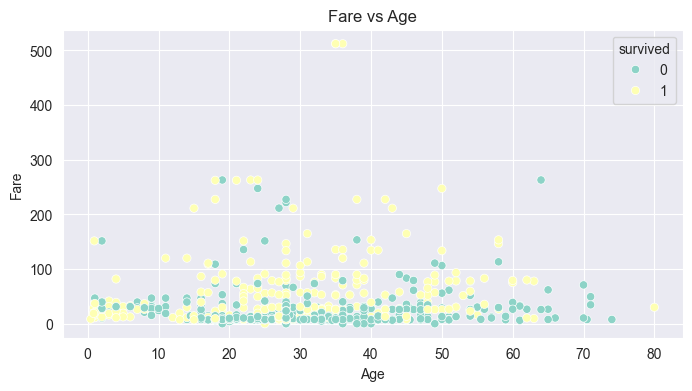

In [80]:
# Scatter Plot on Age vs Fare separating the survival status as well

plt.figure(figsize=(8, 4))
sns.scatterplot(data=titanic, x = 'age', y = 'fare', hue='survived')
plt.title('Fare vs Age')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()


### 4.2.2 From the bivariate scatter plot, we observed age and fare relate to survival status. Can we delve deeper into how age/fare alone is distributed among those who survived and those who didn't?

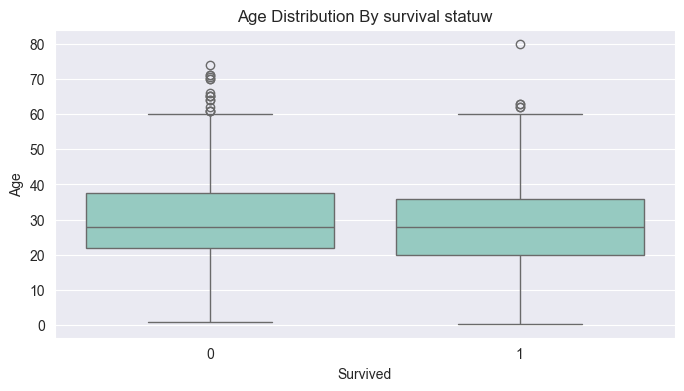

In [85]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=titanic, x='survived',y='age')
plt.title('Age Distribution By survival statuw')
plt.xlabel('Survived')
plt.ylabel('Age')
plt.show()

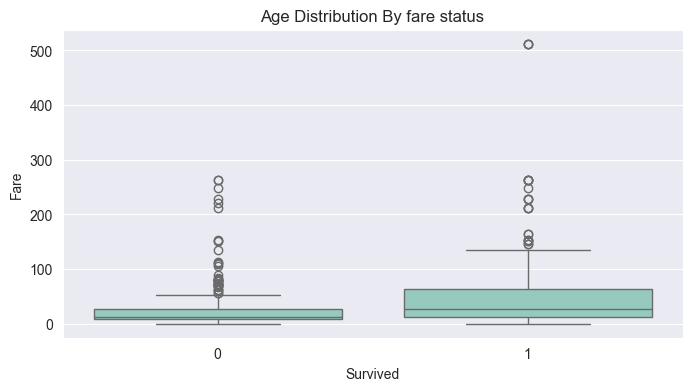

In [88]:
plt.figure(figsize=(8, 4))
sns.boxplot(data=titanic, x='survived',y='fare')
plt.title('Age Distribution By fare status')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.show()


4.3 Multivariate Analysis
Multivariate analysis refers to a set of statistical techniques used to analyze data that involves more than two variables. It is a crucial part of data analysis that allows researchers to understand the relationships and interactions among multiple variables simultaneously. By examining multiple variables at once, we can gain deeper insights into complex datasets and uncover patterns that may not be evident when analyzing each variable in isolation.

Multivariate analysis helps in exploring how several variables interact with each other and identifying underlying relationships. This can be done by correlation analysis of multiple variables simulataneously using heat maps and pair plots.



Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')


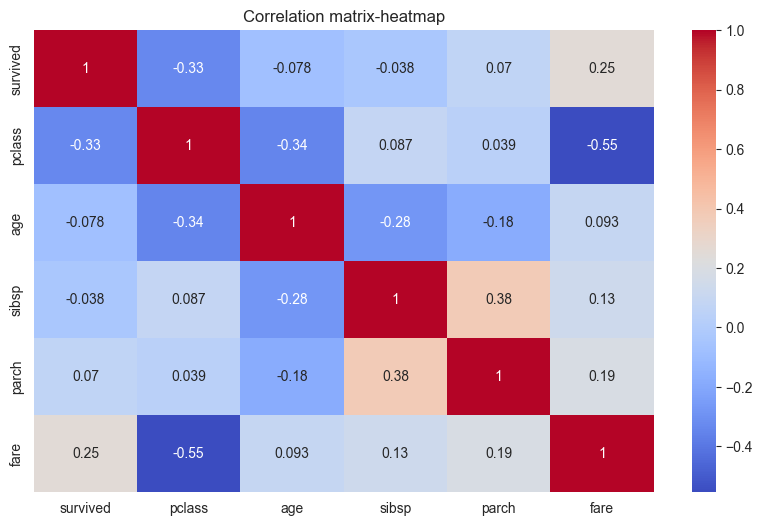

In [90]:
plt.figure(figsize=(10,6))
numerical_cols = titanic.select_dtypes(include=[np.number])
print(numerical_cols.columns)
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation matrix-heatmap')
plt.show()


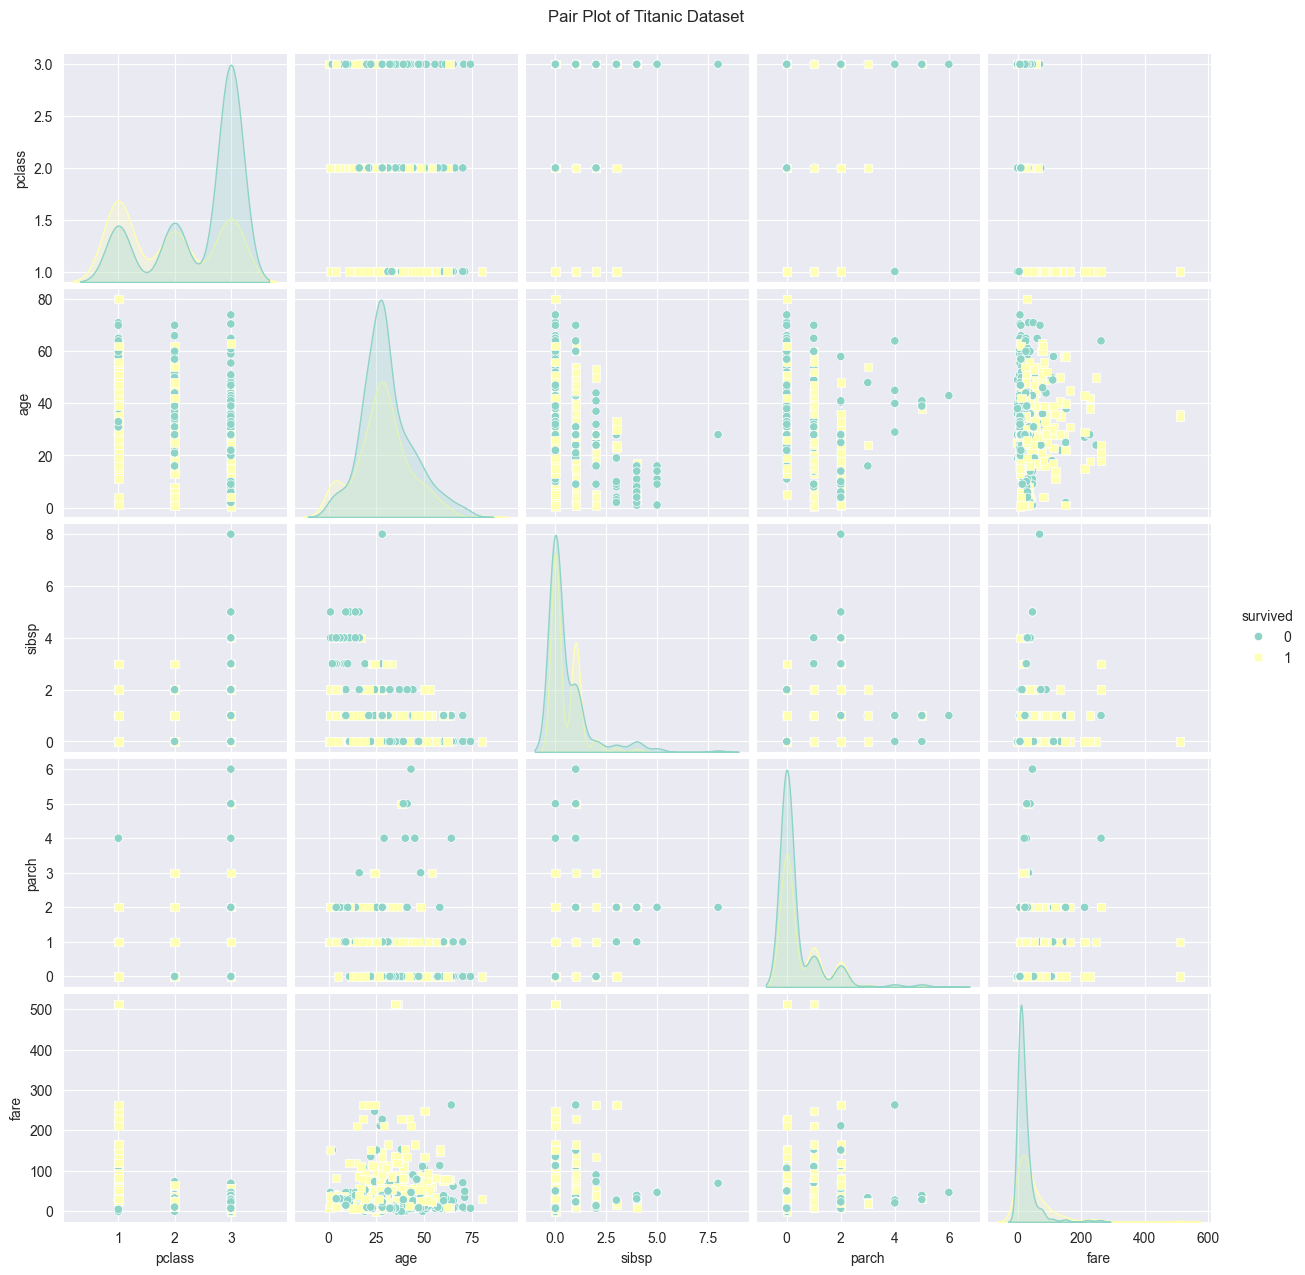

In [91]:
# Visualizing the relationships using pair plot
sns.pairplot(titanic, hue='survived', diag_kind='kde', markers=['o', 's'])
plt.suptitle('Pair Plot of Titanic Dataset', y=1.02)
plt.show()

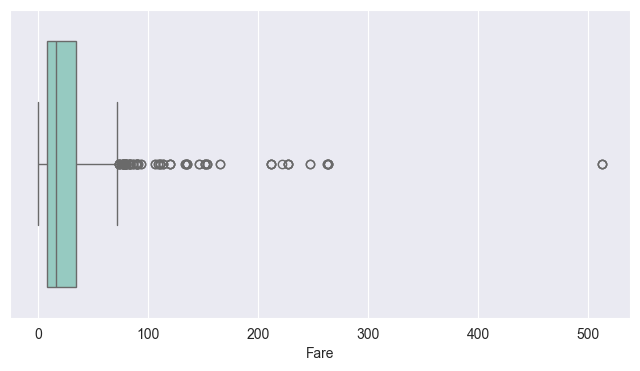

     survived  pclass     sex   age  sibsp  parch      fare embarked  class  \
1           1       1  female  38.0      1      0   71.2833        C  First   
27          0       1    male  19.0      3      2  263.0000        S  First   
31          1       1  female  28.0      1      0  146.5208        C  First   
34          0       1    male  28.0      1      0   82.1708        C  First   
52          1       1  female  49.0      1      0   76.7292        C  First   
..        ...     ...     ...   ...    ...    ...       ...      ...    ...   
829         1       1  female  62.0      0      0   80.0000        S  First   
835         1       1  female  39.0      1      1   83.1583        C  First   
849         1       1  female  28.0      1      0   89.1042        C  First   
856         1       1  female  45.0      1      1  164.8667        S  First   
879         1       1  female  56.0      0      1   83.1583        C  First   

       who adult_male  embark_town alive  alone  
1

In [96]:
# Visualizing outliers in 'Fare' before treatment

plt.figure(figsize=(8,4))
sns.boxplot(x=titanic['fare'])
plt.xlabel('Fare')
plt.show()

Q1 = titanic['fare'].quantile(0.25)
Q3 = titanic['fare'].quantile(0.75)
IQR = Q3-Q1
fare_lower_bound = Q1 - 1.5*IQR
fare_higher_bound = Q3 + 1.5*IQR

fare_outliers = titanic[(titanic['fare'] < lower_bound) | (titanic['fare'] > higher_bound)]
print(fare_outliers)

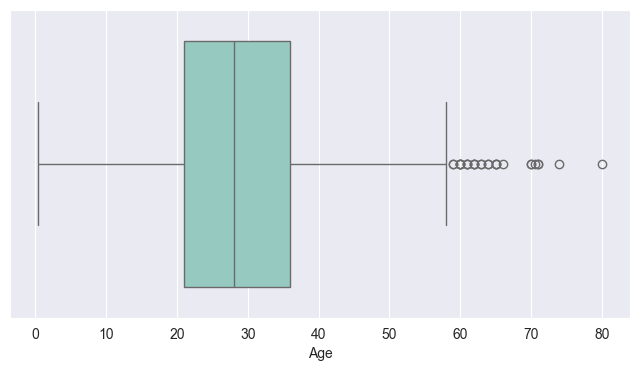

     survived  pclass     sex   age  sibsp  parch      fare embarked   class  \
33          0       2    male  66.0      0      0   10.5000        S  Second   
54          0       1    male  65.0      0      1   61.9792        C   First   
94          0       3    male  59.0      0      0    7.2500        S   Third   
96          0       1    male  71.0      0      0   34.6542        C   First   
116         0       3    male  70.5      0      0    7.7500        Q   Third   
170         0       1    male  61.0      0      0   33.5000        S   First   
232         0       2    male  59.0      0      0   13.5000        S  Second   
252         0       1    male  62.0      0      0   26.5500        S   First   
275         1       1  female  63.0      1      0   77.9583        S   First   
280         0       3    male  65.0      0      0    7.7500        Q   Third   
326         0       3    male  61.0      0      0    6.2375        S   Third   
366         1       1  female  60.0     

In [97]:
# Visualizing outliers in 'age' before treatment

plt.figure(figsize=(8,4))
sns.boxplot(x=titanic['age'])
plt.xlabel('Age')
plt.show()

Q1 = titanic['age'].quantile(0.25)
Q3 = titanic['age'].quantile(0.75)
IQR = Q3-Q1
age_lower_bound = Q1 - 1.5*IQR
age_higher_bound = Q3 + 1.5*IQR

age_outliers = titanic[(titanic['age'] < lower_bound) | (titanic['age'] > higher_bound)]
print(age_outliers)

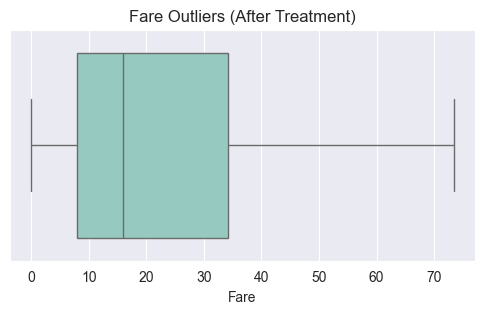

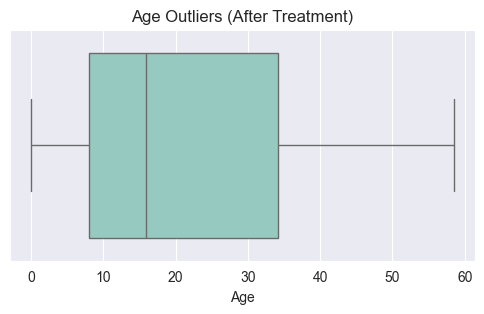

In [100]:
# Treating fare outliers by capping
titanic['fare'] = titanic['fare'].apply(lambda x: fare_lower_bound if x < fare_lower_bound else fare_higher_bound if x > fare_higher_bound else x)
titanic['age'] = titanic['age'].apply(lambda x: age_lower_bound if x < age_lower_bound else age_higher_bound if x > age_higher_bound else x)

# Visualizing outliers in 'Fare' after treatment
plt.figure(figsize=(6, 3))
sns.boxplot(x=titanic['fare'])
plt.title('Fare Outliers (After Treatment)')
plt.xlabel('Fare')
plt.show()


# Visualizing outliers in 'Age' after treatment
plt.figure(figsize=(6, 3))
sns.boxplot(x=titanic['age'])
plt.title('Age Outliers (After Treatment)')
plt.xlabel('Age')
plt.show()


In [101]:
# Feature Engineering
## 5.1 Converting Categorical Features to Numerical

# Converting categorical features (4 columns) to numerical using one-hot encoding
titanic = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who'], drop_first=True)
titanic.head()


,survived,pclass,age,sibsp,parch,fare,adult_male,embark_town,alive,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,0,3,7.250,1,0,7.2500,True,Southampton,no,False,True,False,True,False,True,True,False
1,1,1,58.500,1,0,71.2833,False,Cherbourg,yes,False,False,False,False,False,False,False,True
2,1,3,7.925,0,0,7.9250,False,Southampton,yes,True,False,False,True,False,True,False,True
3,1,1,53.100,1,0,53.1000,False,Southampton,yes,False,False,False,True,False,False,False,True
4,0,3,8.050,0,0,8.0500,True,Southampton,no,True,True,False,True,False,True,True,False


In [107]:
# Creating new features

titanic['family_size'] = titanic['sibsp']  + titanic['parch'] + 1
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)
titanic['fare_per_person'] = titanic['fare']/titanic['family_size']
titanic.head()


,survived,pclass,age,sibsp,parch,fare,adult_male,embark_town,alive,alone,...,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,family_size,is_alone,fare_person,fare_per_person
0,0,3,7.250,1,0,7.2500,True,Southampton,no,False,...,False,True,False,True,True,False,2,0,3.62500,3.62500
1,1,1,58.500,1,0,71.2833,False,Cherbourg,yes,False,...,False,False,False,False,False,True,2,0,35.64165,35.64165
2,1,3,7.925,0,0,7.9250,False,Southampton,yes,True,...,False,True,False,True,False,True,1,1,7.92500,7.92500
3,1,1,53.100,1,0,53.1000,False,Southampton,yes,False,...,False,True,False,False,False,True,2,0,26.55000,26.55000
4,0,3,8.050,0,0,8.0500,True,Southampton,no,True,...,False,True,False,True,True,False,1,1,8.05000,8.05000


Visualizing new features:


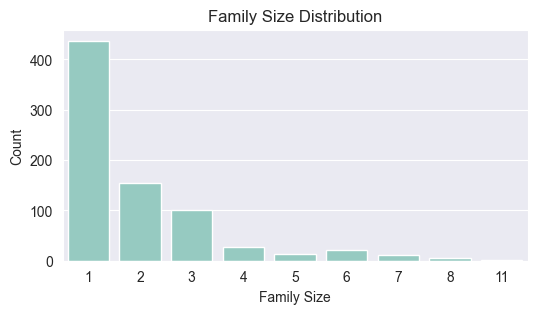

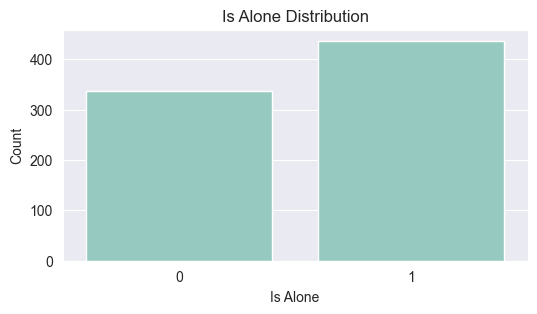

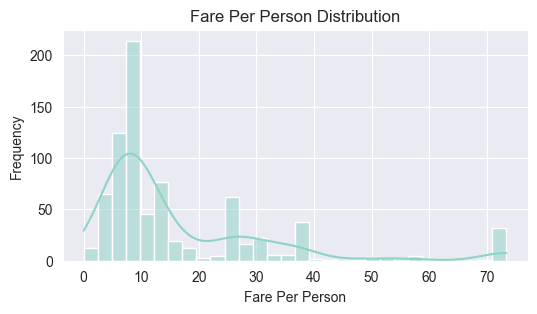

In [108]:
# Visualizing the new features
# Family Size Distribution
plt.figure(figsize=(6, 3))
sns.countplot(x='family_size', data=titanic)
plt.title('Family Size Distribution')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.show()

# Is Alone Distribution
plt.figure(figsize=(6, 3))
sns.countplot(x='is_alone', data=titanic)
plt.title('Is Alone Distribution')
plt.xlabel('Is Alone')
plt.ylabel('Count')
plt.show()

# Fare Per Person Distribution
plt.figure(figsize=(6, 3))
sns.histplot(titanic['fare_per_person'], bins=30, kde=True)
plt.title('Fare Per Person Distribution')
plt.xlabel('Fare Per Person')
plt.ylabel('Frequency')
plt.show()


Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'embark_town', 'alive', 'alone', 'sex_male', 'embarked_q', 'embarked_s',
       'class_second', 'class_third', 'who_man', 'who_woman', 'family_size',
       'is_alone', 'fare_person', 'fare_per_person'],
      dtype='str')


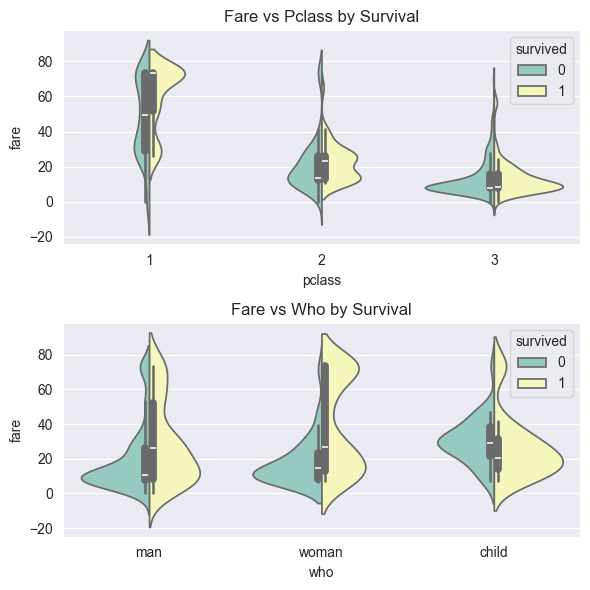

In [109]:
##Violin Plots

import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'titanic' DataFrame is properly loaded
# Assuming 'titanic' DataFrame is already loaded

# Check and standardize column names
titanic.columns = titanic.columns.str.strip().str.lower()
print(titanic.columns)

# Create a new 'who' column based on 'who_man' and 'who_woman'
titanic['who'] = titanic.apply(lambda row: 'man' if row['who_man'] == 1 else ('woman' if row['who_woman'] == 1 else 'child'), axis=1)

# Create subplots for violin plots
fig, axes = plt.subplots(2, 1, figsize=(6, 6))

# Violin plot for Fare vs Pclass by Survival
sns.violinplot(x='pclass', y='fare', hue='survived', data=titanic, split=True, ax=axes[0])
axes[0].set_title('Fare vs Pclass by Survival')

# Violin plot for Fare vs Who by Survival
sns.violinplot(x='who', y='fare', hue='survived', data=titanic, split=True, ax=axes[1])
axes[1].set_title('Fare vs Who by Survival')

plt.tight_layout()
plt.show()

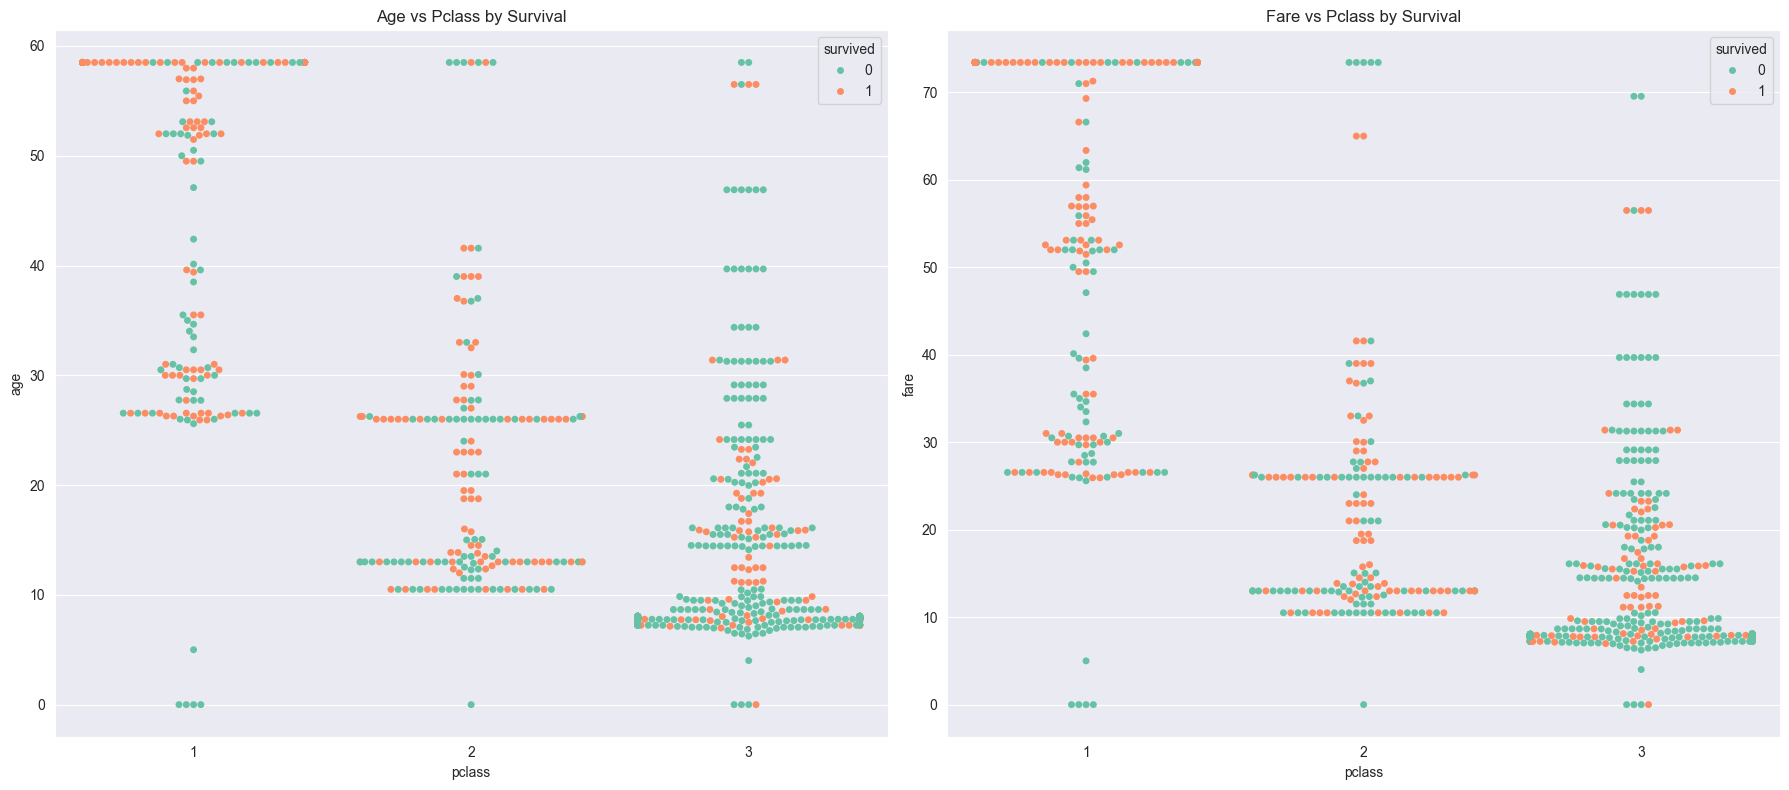

In [110]:
### Swarm Plots

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.swarmplot(x='pclass', y='age', hue='survived', data=titanic, ax=axes[0], palette='Set2')
axes[0].set_title('Age vs Pclass by Survival')
sns.swarmplot(x='pclass', y='fare', hue='survived', data=titanic, ax=axes[1], palette='Set2')
axes[1].set_title('Fare vs Pclass by Survival')
plt.tight_layout()
plt.show()

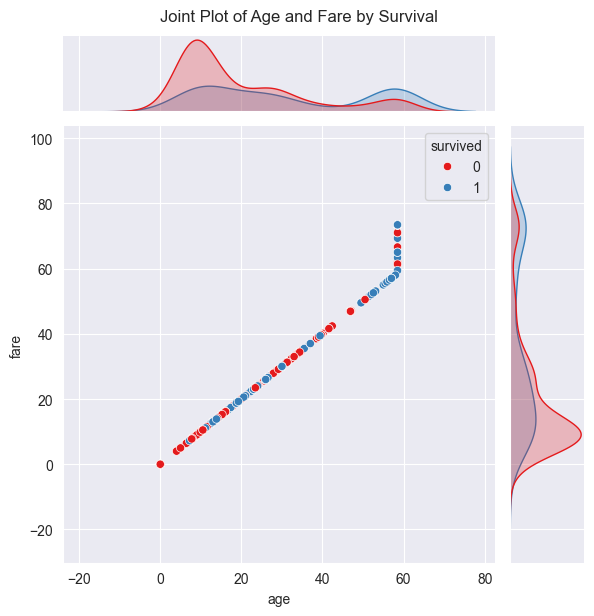

In [111]:
##Joint Plots

sns.jointplot(x='age', y='fare', data=titanic, kind='scatter', hue='survived', palette='Set1')
plt.suptitle('Joint Plot of Age and Fare by Survival', y=1.02)
plt.show()